<div style="display: flex; justify-content: space-between;">
<div style="text-align: left; display: inline-block;" align="left"><b>Tepper School of Business </b></div>
<div style="text-align: right; display: inline-block;" align="right"><i>Copyright Dennis Epple</i></div>
</div>
<hr>
<div style="display: flex; justify-content: space-between;">
<div style="text-align: left" align="left">Statistical Decision Making (45-752)</div>
</div>

# Application to CEO Pay


## Introduction

This investigation has broadly two objectives. One is to help you improve your skills in data analysis. The other is to help you learn about firms in the US economy. In particular, we will study the distribution of firm sizes as measured by two key variables, firm value (stock market capitalization) and number of employees. We will also study executive compensation, and we will investigate how executive compensation varies with firm value, number of firm employees, and the industry in which the firm operates. In this analysis, you will also learn about the US system for classifying industries. I think you will find this to be very interesting and informative.

In [187]:
# This command installs tprstats from its GitHub repo. You only need to run this command once, when start the notebook.
#!pip install git+https://github.com/dnepple/tprstats-python@colab

# stress test to see if this is a good solution to problem of installing tprstats
try:
    import tprstats
except ImportError as e:
  !pip install git+https://github.com/dnepple/tprstats-python@colab
  import tprstats

In [188]:
# import the google drive package
from google.colab import drive
# mount google drive
drive.mount('/content/drive')
# set the working directory to the course folder. SDM is an abbreviation of Statistical Decision Making.
%cd '/content/drive/MyDrive/SDM'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/SDM


In [189]:
import pandas
import matplotlib.pyplot as plt
import numpy
from scipy import stats
import statsmodels.api as sm
# Jupyter "magic" command
# precision - round floats to 4 significant digits
%precision %.4f

'%.4f'

## Overview of The Data

In preparing this data set, I assembled data for year 2022 for all US firms that have more than 99 employees and also have CEO compensation more than \$99,000. The result is a total of 992 firms.

 The data are in a file named CEO_Comp_dat.xlsx. Import give the shorthand name USFirms.

In [140]:
import pandasimport numpy
from scipy import stats
import matplotlib.pyplot as plt

In [190]:
# Import data set
USFirms = pandas.read_excel("data/CEO_Comp_Dat.xlsx")

For convenience for the analysis below, let's extract CEO Total Direct Compensation (TDC1), number of employees, market capitalization, gender, and Standard Industrial Capitalization 2-Digit codes (SIC2). We can then use the variables without having to including the names of the file in which the variables reside. Let's name the first three variables Comp, Emp, and MktCap respectively. In our data, both Comp and MktCap are expressed in millions of dollars. The Standard Industrial Capitalization codes are explained in the next section.

In [191]:
Comp = USFirms["TDC1"]
Emp = USFirms["Employees"]
MktCap = USFirms["MktCap"]
Gender = numpy.where(USFirms["GENDER"] == "MALE", 0, 1)
SIC2 = USFirms["SIC2"]
YRS_CEO = USFirms["YRS_CEO"]
Age = USFirms["AGE"]

Let's calculate the combined market capitalization of the firms in our sample. We find that the 992 firms in our sample had combined market capitalization of \\$24.91 trillion. By way of comparison, the value of all US stocks at the end of 2022 was \\$40.512. Hence, the combined value of the 992 firms in our data set comprised roughly 62% of total stock market capitalization in the US.

Source of data for value of all US Stocks: <https://siblisresearch.com/data/us-stock-market-value/>

In [192]:
MktCap.sum()

np.float64(25506439.954559997)

The firms in our sample had a combined total of 25,485,622 employees. The total number of employed workers in the us at the end of 2022 was 159,244,000. Hence, the firms in our sample employed 16% of the US workforce.

Source of data for combined total employment: <https://www.bls.gov/news.release/empsit.t01.htm>

In [193]:
Emp.sum()

np.int64(25485622)

The combined compensation of the 992 CEOs in our data was $9.437 billion.

In [194]:
Comp.sum()

np.float64(9483.562727)

In [195]:
# Alternatively, we can use the following command to select the subset of columns from the dataset
# and then use sum on the subset to get all sums at once.
USFirms[["TDC1", "Employees", "MktCap"]].sum()

,0
TDC1,9.483563e+03
Employees,2.548562e+07
MktCap,2.550644e+07


The data set I assembled reports total compensation of each CEO in 2022. The data do not provide details of the form of CEO compensation. In most firms, a large proportion of CEO compensation comes in the form of vested stocks. Such vesting of stocks provides an incentive for the CEO to devote effort to increasing the market capitalization of the company, which in turn benefits the owners of the company, i.e., shareholders.

Source: If you wish to delve into the theoretical and empirical underpinnings of such compensation arrangements, I recommend: George-Levi Gayle, Chen Li, and Robert A. Miller, "How Well Does Agency Theory Explain Executive Compensation?," Federal Reserve Bank of St. Louis Review, Third Quarter 2018, 100(3), pp. 201-36. <https://doi.org/10.20955/r.100.201-36>

## Standard Industrial Classification Codes

It is useful for you to have an understanding of the US Standard Industrial Classification (SIC) system. Each US firm is classified by the US government with a four-digit SIC code. The first two digits of the code are the industry in which the firm operates. The next two codes denote the particular focus of the firm. For our regression analysis below, we will use the two-digit codes. The tables in Appendix A list the two-digit codes and the associated industries. The link in the following footnote leads you to the list of four-digit codes. I suggest you take a moment to view that list.

Source: <https://www.bls.gov/oes/special-requests/oessic87.pdf>

Here is an example. The primary four-digit code for Apple is 3663. The first two digits of this code, 36, and the table in Appendix A tell us that the industry in which Apple is classified is "Electronic and Other Electronic Equipment". If you go to the link in the footnote to the previous paragraph you will find that 3663 is: "Radio and Television Broadcasting and Communications Equipment". This classification is obviously due to Apple's focus on Communications Equipment. A second SIC code for Apple is is 3571, which is "Electronic Computers." The US government classification system only extends to four digits. You will sometime see codes with more than four digits. Such codes may be informative, but you should be aware that SIC codes with more than four digits are from a privately created coding system.

Appendix B provides a count of the number of firms in our sample that are in each SIC 2-digit industry. If you peruse this appendix, you will see that firms from 59 different industries are in our sample. You will also see that the industry with the largest number of firms is Business Services. It is entirely coincidental that the number of firms in Business Services, 73, is the same as SIC code for Business Services. You will also see that two firms have SIC code 99, which denotes Non-Classifiable Establishments. You might think these are obscure firms, but if you look at our data file, you will see that those two firms are Honeywell and General Electric.

Source: If you look at the web page for Honeywell, you will see the remarkably diverse range of products it sells: <https://www.honeywell.com/us/en/industries/products>. Likewise, if you go to General Electric's home page, you will see the remarkable range of businesses in which it operates: <https://www.ge.com/>

## The Twelve Firms with Highest Market Capitalization

Let's investigate the data for the firms with the highest market capitalization in 2022. After some preliminary investigation with the command below, I found that there were 12 firms with market capitalization greater than 250 billion dollars. The first command below extracts the data for these 12 firms. The second command selects variables for the table presented below. We see that three firms had market capitalization greater than one trillion. In descending order of market capitalization, they are Apple, Microsoft, and Amazon. As you can see, the CEO's of these three companies received \\$99.4 million, \\$54.9 million, and \\$22.498 million. From the table, we also see that there is enormous variation across these twelve firms in number of employees, ranging from 2.3 million at Walmart to 20,000 at Broadcom.

By way of comparison, IBM had the highest market capitalization on January 1, 1991, \\$65.56 trillion. Adjusted for inflation to 2022 dollars, this would be \\$142.273 trillion.

In [196]:
TopMktCap = USFirms.query("MktCap>250000")
TopMktCap[["CompanyName", "MktCap", "ExecName", "TDC1", "Employees", "SIC2"]]

,CompanyName,MktCap,ExecName,TDC1,Employees,SIC2
6,Apple,2750000.0,Timothy Cook,99.420097,164000,36
54,Amazon,1210000.0,Andrew Jassy,22.498723,1541000,59
84,Broadcom,283000.0,Hock E. Tan,60.606971,20000,36
420,Home Depot,299000.0,Edward Decker,14.515600,500000,52
514,JPMorgan Chase,408000.0,James Dimon,34.818729,293723,60
533,Coca-Cola,272000.0,James Quincey,22.332484,79000,20
602,Meta (Facebook),633000.0,Mark Zuckerberg,27.110418,86482,73
625,Microsoft,2370000.0,Satya Nadella,54.946309,221000,73
720,Pepsico,264000.0,Ramon Luis Laguarta,24.136449,315000,20
723,Procter & Gamble,360000.0,Jon Moeller,17.716015,106000,28


Together, the above 12 firms had a market capitalization of 9.75 trillion dollars. The total value of the US stock market was \$40.5 trillion. Hence, the value of these 12 firms combined was 24% of the value of all US stocks!

In [197]:
TopMktCap["MktCap"].sum()

np.float64(9747000.0)

## Looking at Data

In your summer internship and your future work, you will very likely gather data (or have people who report to you gather data). When you have created a dataset, it is important for you to know how to "look at the data". We have already done so in previous applications, so the approach will be familiar to you. Also, we have already begun looking at the current data set in the investigations in the preceding sections of this chapter. We will now investigate the full sample in more detail. As you know, summary statistics, histograms, and graphs are useful ways to look at data.

## Summary Statistics for The Full Sample

We see from the summary statistics below that the firm with the largest number of employees has 2.3 million employees. That firm is Walmart. We see that the firm with the largest market capitalization has value \$2.75 trillion. That firm is Apple. The CEO of Apple received \$99.42 million in 2022. While not shown in the summary statistics, the highest paid female executive was the CEO of Citigroup, Jane Nind Fraser, who earned \$22.06 million in 2022. The median of CEO compensation is \$7,507,078. Hence, half of the CEO's in our sample earned more than \$7,507,078 and half earned less. We have an even number of observations. Hence, the reported median is between the pay of the two CEO's. One is the CEO of IDEX, a national securities exchange for trading of U.S. equities; the other is the CEO of TD SYNNEX, which provides information technology products and business process services. The lowest paid executive in this group is Bernard Francis Saul II who earned \$245,860. He is the CEO of a real estate investment trust named Saul Centers Inc.  

View summary statistics. We see that median CEO age was 58. Maxiumum CEO compensation was \$99,420,000. Three fourths of the firms had 18,700 or fewer employees. Average number of years as CEO was 8.25.

In [198]:
USFirms[["TDC1", "Employees", "MktCap", "SIC2", "YRS_CEO", "AGE"]].describe().round(3)

,TDC1,Employees,MktCap,SIC2,YRS_CEO,AGE
count,992.000,992.000,992.000,992.000,992.000,992.000
mean,9.560,25691.151,25712.137,46.992,8.253,58.217
std,8.334,99350.687,129063.759,18.843,7.335,6.749
min,0.246,105.000,4.582,10.000,1.000,35.000
25%,4.550,2000.000,1772.954,35.000,3.000,54.000
50%,7.507,6300.000,4692.807,48.000,6.000,58.000
75%,12.047,18700.000,15978.638,62.000,10.000,62.000
max,99.420,2300000.000,2750000.000,99.000,43.000,90.000


For some of the analysis below, we will use logarithms of our three main variables. The logarithms are created here. We will also use the square of the logarithm of employment, so that variable is also calculated below.

In [199]:
logComp = USFirms["TDC1"].apply(numpy.log)
logMktCap = USFirms["MktCap"].apply(numpy.log)
logEmp = USFirms["Employees"].apply(numpy.log)
logEmp_sq = logEmp.apply(numpy.square)

For illustrative purposes, here's an example of how you can take the log of multiple variables, relabeling the variables with the prefix "log_". This is not something you are expected to know for this course, but may be useful to you in the future when batch processing data.

In [200]:
logs = USFirms[["TDC1", "MktCap", "Employees"]].apply(numpy.log)
# prepend 'log_' to each column
logs.columns = ["log_" + col for col in logs.columns]
# square of log of employment
logs["log_Emp_sq"] = logs["log_Employees"].apply(numpy.square)
logs

,log_TDC1,log_MktCap,log_Employees,log_Emp_sq
0,2.812255,10.550249,9.781320,95.674219
1,2.552363,8.789803,9.409191,88.532880
2,1.586507,9.192745,11.772979,138.603043
3,1.776470,5.995217,9.123693,83.241766
4,1.816332,8.509992,7.965893,63.455447
...,...,...,...,...
987,1.233163,6.205358,7.406711,54.859364
988,2.342883,5.645676,7.901007,62.425912
989,1.361322,8.302581,9.209240,84.810097
990,2.639310,11.327207,9.400961,88.378063


## Investigation of the Distributions of The Variables

### Distribution of Number of Employees

The distribution of number of employees is highly skewed to the right. This histogram is not very informative. Please do histograms of market capitalization and CEO compensation. You will see that those two variables are also highly skewed.

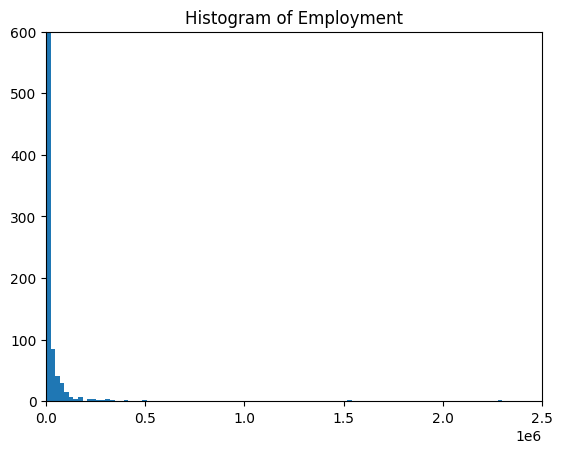

In [201]:
plt.hist(Emp, bins=100)
plt.xlim(0, 2500000)
plt.ylim(0, 600)
plt.title("Histogram of Employment")
plt.show()

When working with skewed distributions, it is often informative to work with logs. We see that the histogram of the logarithm of employment is relatively symmetric.

 Recall that logarithms can only be taken for numbers that are positive. All values are positive in our current application.

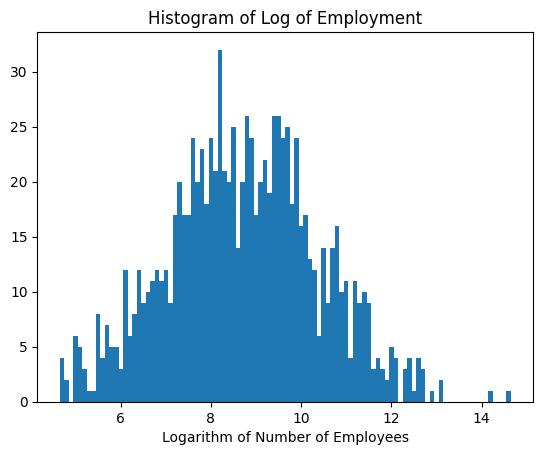

In [202]:
plt.hist(logEmp, bins=100)
plt.xlabel("Logarithm of Number of Employees")
plt.title("Histogram of Log of Employment")
plt.show()

### Distribution of Market Capitalization.

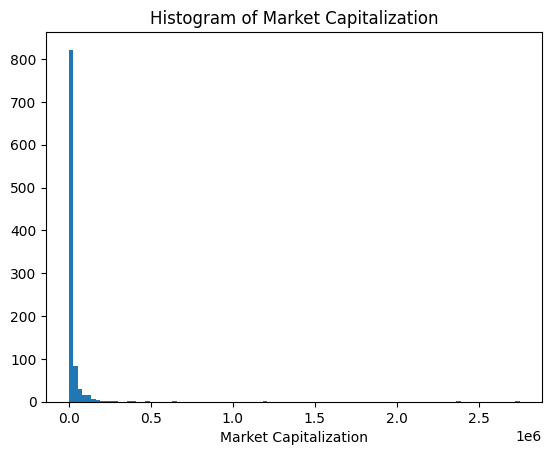

In [203]:
plt.hist(MktCap, bins=100)
plt.xlabel("Market Capitalization")
plt.title("Histogram of Market Capitalization")
plt.show()

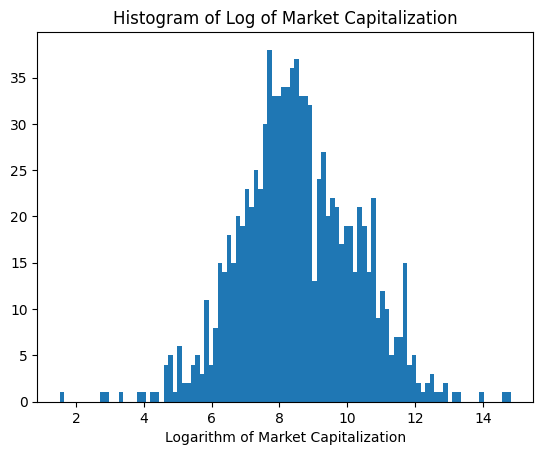

In [204]:
plt.hist(logMktCap, bins=100)
plt.xlabel("Logarithm of Market Capitalization")
plt.title("Histogram of Log of Market Capitalization")
plt.show()

In tprstats, we have incorporated a feature that fits a distribution to data. The next cell shows you how to use the command to fit a distribution to the logarithm of market capitalization. When you run the command, you will see that it chooses the t-distribution. Ignore the warning message.

In [205]:
tprstats.select_distribution(logMktCap)

/usr/local/lib/python3.12/dist-packages/tprstats/fit_distribution.py:32: RuntimeWarning: divide by zero encountered in log
  log_likelihood = np.sum(np.log(dist.pdf(data, *params)))


't'

We find that the logarithm of market capitalization has the t-distribution. Informally speaking, this tells us that there are relatively large outliers on the upper and lower ends of the distribution, more than we would obtain with a normal distribution. Either of the following is correct: In our sample of firms, MktCap has the log-t distribution; logMktCap has the t-distribution.

The variable YRS_CEO contains, for each of the 992 firms in our sample, the number of years that the firm's CEO has been CEO. The number of years as CEO is relatively skewed.

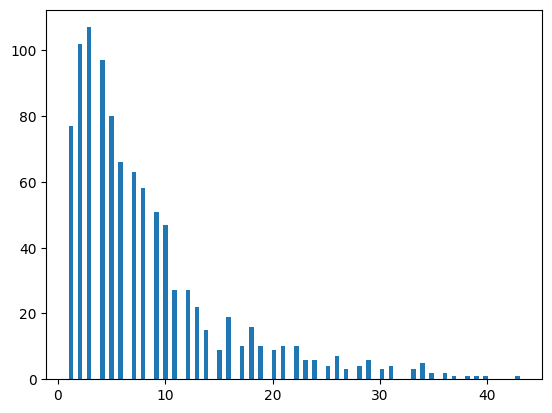

In [206]:
plt.hist(YRS_CEO, bins=100)
plt.show()

### Distribution of CEO Compensation

Not surprisingly, the distribution of CEO compensation is skewed to the right. We saw in our above summary table for the twelve firms with the highest market capitalization that some CEO's in our sample are very highly paid.

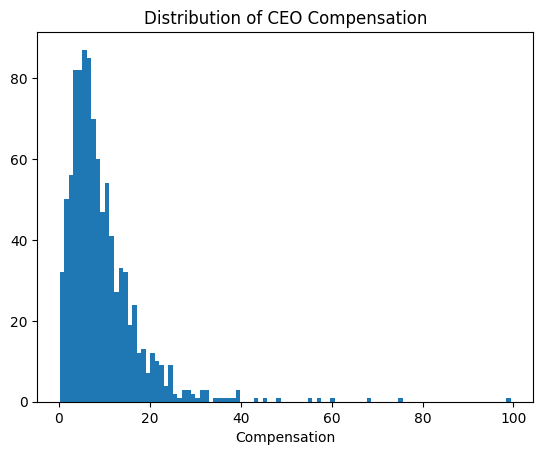

In [207]:
plt.hist(Comp, bins=100)
plt.title("Distribution of CEO Compensation")
plt.xlabel("Compensation")
plt.show()

We see below that the distribution of the logarithm of CEO compensation is somewhat skewed to the left. Some CEOs in our sample have **relatively** low compensation. That said, we saw in the summary statistics that the lowest-paid CEO in our sample earned \$245,860. This is high compensation relative to the vast majority of workers in the US.

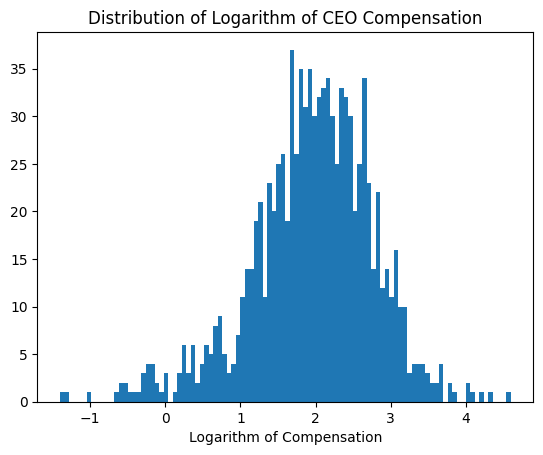

In [208]:
plt.hist(logComp, bins=100)
plt.title("Distribution of Logarithm of CEO Compensation")
plt.xlabel("Logarithm of Compensation")
plt.show()

## Analysis of Predictors of CEO Pay

### Graphical Investigation

The objective of the analyses that follow is to investigate how much of the variation in CEO pay can be predicted using market capitalization and number of firm employees. We will begin by doing bivariate plots.

We first plot CEO compensation against market capitalization. The graph on the left below plots the unlogged variables. It is not very informative. The graph on the right plots the variables in logged form. In the latter we see that there is a tendency for CEO pay to increase with market capitalization. You are not required to know how to do the side-by-side plots, but I thought you might like to see how it is done. The subplots(1, 2, figsize=(10, 4)) command tells Python to place the plots in one row and two columns. The second and third commands create the plots.

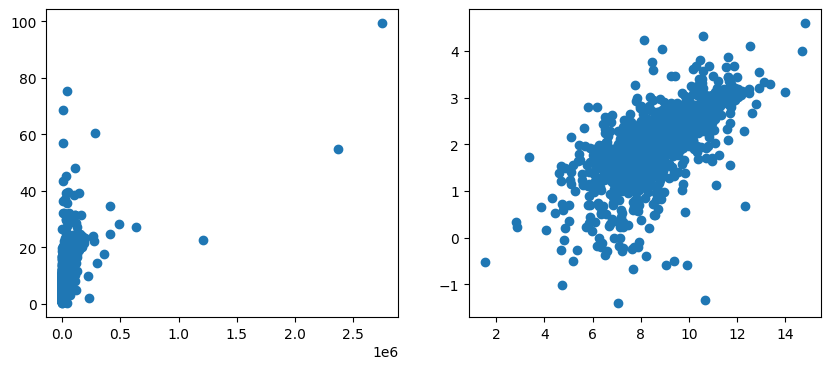

In [209]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(MktCap, Comp)
axes[1].scatter(logMktCap, logComp)
plt.show()

We next plot CEO compensation against number of employees. The graph on the left below plots the unlogged variables. It is not very informative. The graph on the right plots the variables in logged form. In the latter we see that there is a tendency for pay to increase with number of firm employees.

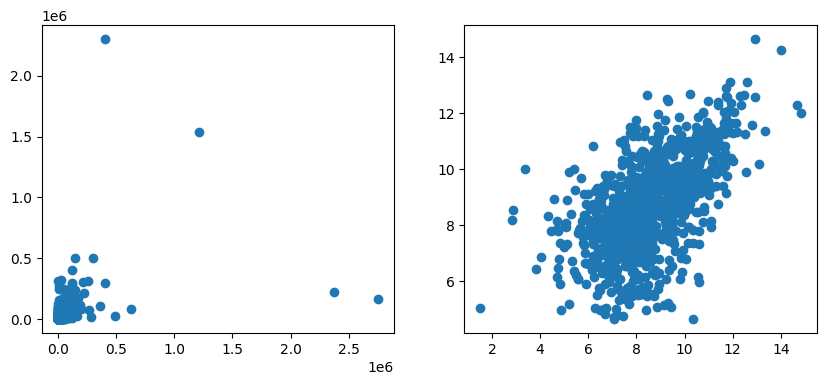

In [210]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(MktCap, Emp)
axes[1].scatter(logMktCap, logEmp)
plt.show()

## Regression with Model Linear in Variables

The above bivariate graphs are of interest in giving us a feel for the data. To investigate the combined effect of market capitalization and firm employment in predicting CEO pay, we will use regression. Let's begin with a regression with CEO compensation as the dependent variable and firm employment and market capitalization as independent variables. From the p-values, we see that market capitalization is a significant predictor of CEO pay but number of employees is not.

In [211]:
PayReg1 = tprstats.model("cs", "TDC1~Employees+MktCap", USFirms)
PayReg1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   TDC1   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.257
No. Observations:                 992   F-statistic:                     22.85
Covariance Type:                  HC1   Prob (F-statistic):           1.99e-10
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.6338      0.251     34.428      0.000       8.142       9.126
Employees    4.74e-06   5.18e-06      0.915      0.360   -5.42e-06    1.49e-05
MktCap      3.129e-05   4.84e-06      6.461      0.000    2.18e-05    4.08e-05
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 1.48e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Is the above regression a satisfactory functional form? To investigate, let's extract and plot the residuals against the fitted values. The dashed line at zero shows the mean of the residuals. The pattern of the residuals strongly suggests that this model is not satisfactory.

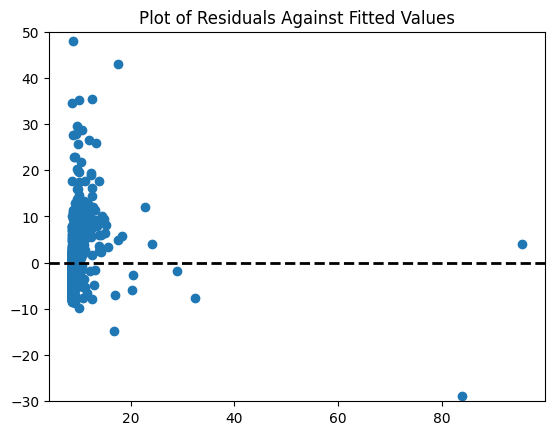

In [212]:
resid=PayReg1.resid
yhat=PayReg1.predict()
plt.scatter(yhat, resid)
plt.axhline(0, linestyle="--", linewidth=2, color="black")
plt.title("Plot of Residuals Against Fitted Values")
plt.ylim(-30, 50)
plt.show()

To investigate further, let's perform the Ramsey test. The very low p-values for Ramsey test reinforce the conclusion that this is not a satisfactory functional form.

In [213]:
PayReg1.ramsey_test()

,power,pvalue
0,2,1.310614e-20
1,3,8.953337e-49


## Regression with Variables Expressed in Logarithmic Form

Let's now use logarithms of the variables. You know from our previous work how to interpret the coefficients of a model with variables expressed in log form; the coefficients are elasticities. Hence, we can interpret the coefficients below as follows. Holding market capitalization constant, a one percent increase in number of employees predicts a .1 percent increase in CEO pay. Holding number of employees constant, a one percent increase in market capitalization predicts a .25% increase in CEO pay. As shown by the $R^2$ statistic, this regression can account for 45% of the variation in CEO pay.

In [214]:
PayReg2=tprstats.model("cs", "log(TDC1)~log(Employees)+log(MktCap)", USFirms)
PayReg2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log(TDC1)   R-squared:                       0.450
Model:                            OLS   Adj. R-squared:                  0.449
No. Observations:                 992   F-statistic:                     372.0
Covariance Type:                  HC1   Prob (F-statistic):          3.52e-121
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.0706      0.124     -8.645      0.000      -1.314      -0.828
log(Employees)     0.0997      0.016      6.129      0.000       0.068       0.132
log(MktCap)        0.2523      0.015     17.320      0.000       0.224       0.281
==================================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

Let's calculate and interpret the standardized coefficients. We see that, holding number of employees constant, a one standard deviation increase in the log of market capitalization predicts an increase of .527 standard deviations of the logarithm of compensation. Holding market capitalization constant, a one standard deviation increase in the log of number of employees predicts an increase of .204 standard deviations of the logarithm of compensation.

In [215]:
PayReg2.standardized_coefficients()

,0
log(Employees),0.204236
log(MktCap),0.527684


Thus, both the elasticities and the standardized coefficients imply that, within our sample, market capitalization of a firm has a substantially larger impact on CEO compensation than number of firm employees.

The p-values below for the Ramsey test are substantially higher for the above regression, but the p-value with one fitted term is still relatively low.

In [216]:
PayReg2.ramsey_test()

,power,pvalue
0,2,0.060853
1,3,0.172407


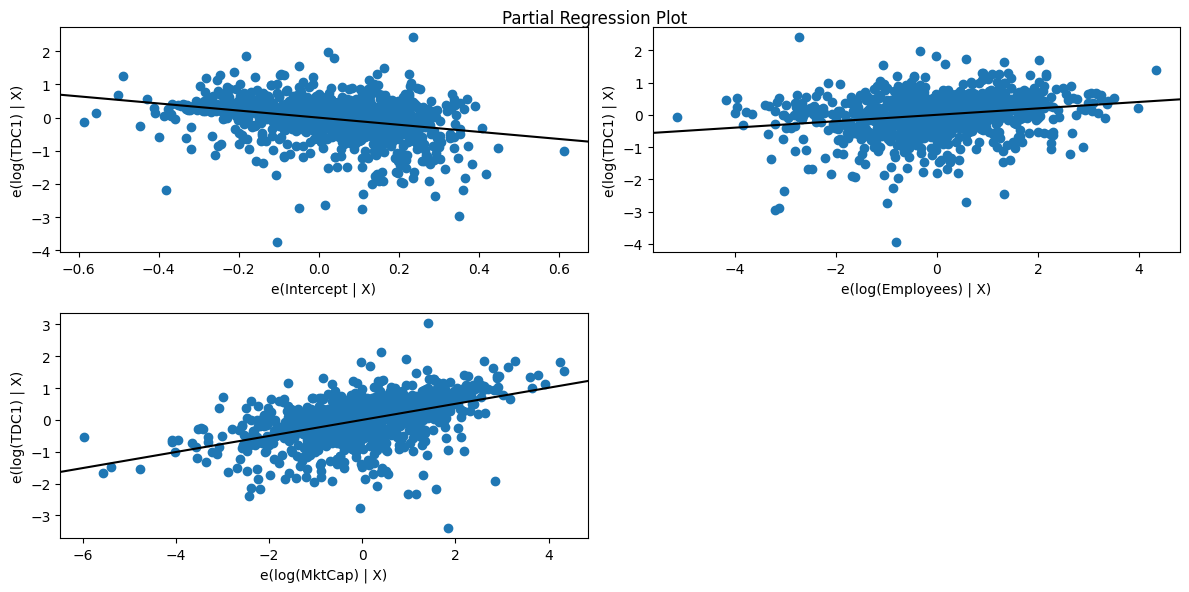

In [217]:
# Display leverage plots
fig = plt.figure(figsize=(12, 6))
sm.graphics.plot_partregress_grid(PayReg2, fig=fig)
plt.show()

In light of the relatively low p-value for the Ramsey test with one fitted term, I included the square of the logarithm of employment. It's p-value is .064, and hence it is relatively significant. I also investigated including the square of logMktCap, but the coefficient was very small and not statistically significant.

I included an indicator variable for gender, the logarithm of years as CEO, and the CEO Age. Note that the coefficient of Gender is small and has a high p-value. Hence, this regression implies that, controlling for company size (market cap and number of employees), there is no material difference in pay between male and female CEOs. CEO age is also insignificant. Moreover, and somewhat surprisingly, CEO pay is not significantly related to the number of years the individual has been CEO. The same is true below when indicator variables for industry are included in the model. The coefficients of logMktCap and the two employment variables are virtually the same with or without the gender and CEO variables. Hence, in the interest of space, I do not report the regression without those variables.

In [218]:
PayReg3=tprstats.model("cs", "log(TDC1)~log(Employees)+log(MktCap)+log(YRS_CEO)+ GENDER", USFirms)
PayReg3.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log(TDC1)   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.450
No. Observations:                 992   F-statistic:                     190.2
Covariance Type:                  HC1   Prob (F-statistic):          7.33e-121
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.1921      0.139     -8.581      0.000      -1.465      -0.919
log(Employees)     0.1030      0.016      6.294      0.000       0.071       0.135
log(MktCap)        0.2503      0.015     17.026      0.000       0.221       0.279
log(YRS_CEO)       0.0307      0.025      1.225      0.221      -0.019       0.080
GENDER[T.MALE]     0.0607      0.062      0.975      0.330      -0.061       0.183
==================================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

Let's view leverage plots of the model.

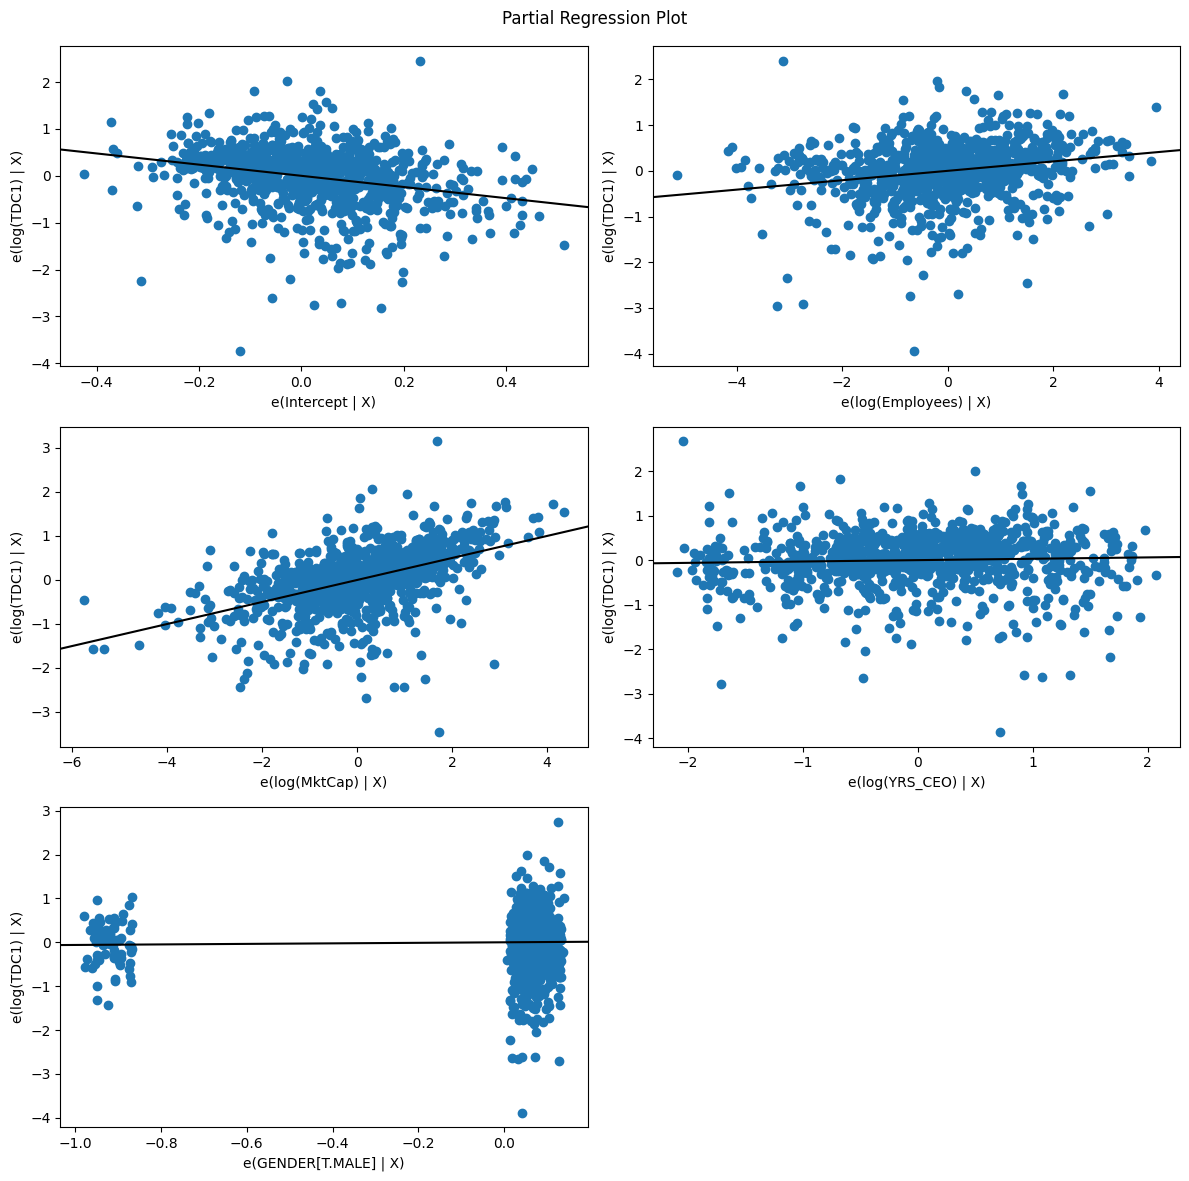

In [219]:
# Display leverage plots
fig = plt.figure(figsize=(12,12))
sm.graphics.plot_partregress_grid(PayReg3, fig=fig)
plt.show()

Visually, thre is greater number of observations below relative to above the line in the top right plot. Hence, I decided to try including the square of the logarithm of employees.

In [220]:
# Include the square of log(Employees) in the regression
PayReg4=tprstats.model("cs", "log(TDC1)~log(Employees)+I(log(Employees)**2)+log(MktCap)+log(YRS_CEO)+AGE", USFirms)
PayReg4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log(TDC1)   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.451
No. Observations:                 992   F-statistic:                     161.4
Covariance Type:                  HC1   Prob (F-statistic):          2.28e-125
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -2.0230      0.496     -4.082      0.000      -2.995      -1.050
log(Employees)             0.2950      0.109      2.708      0.007       0.081       0.509
I(log(Employees) ** 2)    -0.0112      0.006     -1.879      0.061      -0.023       0.000
log(MktCap)                0.2572      0.015     17.325      0.000       0.228       0.286
log(YRS_CEO)               0.0303      0.028      1.072      0.284      -0.025       0.086
AGE                        0.0006      0.004      0.165      0.869      -0.007       0.008
==========================================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 2.42e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The Ramsey Test results are much improved.

In [221]:
PayReg4.ramsey_test()

,power,pvalue
0,2,0.688128
1,3,0.815502


The small standardized coefficients for log(YRs_CEO) and AGE reinforce the inference that those variables are not very important predictors. In what fillows, I retain those variables, but their presence or absence makes litle difference.

In [222]:
PayReg4.standardized_coefficients()

,0
log(Employees),0.604164
I(log(Employees) ** 2),-0.405707
log(MktCap),0.537881
log(YRS_CEO),0.032827
AGE,0.005189


The graph below displays the terms in the logarithm of employment. We see that the curve increases at a decreasing rate and peaks where the log or employment is roughly 13.

<function matplotlib.pyplot.show(close=None, block=None)>

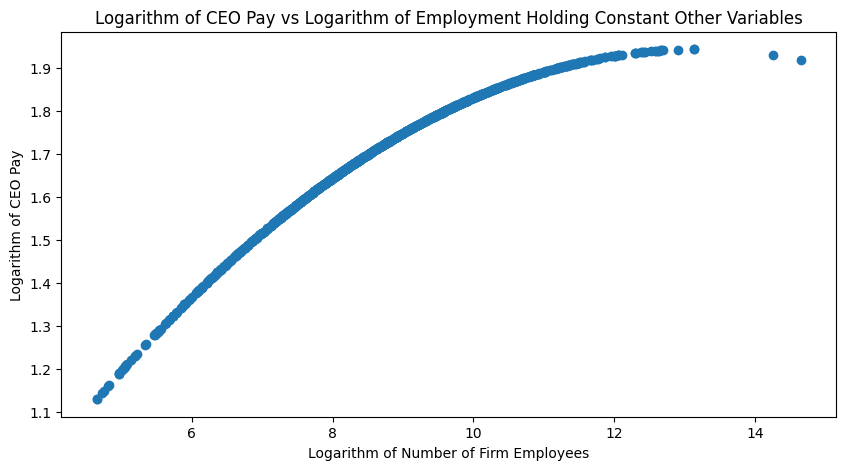

In [223]:
plt.figure(figsize=(10, 5))
Employees=USFirms["Employees"]
log_Emp=numpy.log(Employees)
log_Emp_sq=log_Emp**2
Emp_pred=.2950*log_Emp-.0112*log_Emp_sq
plt.scatter(log_Emp,Emp_pred)
plt.title('Logarithm of CEO Pay vs Logarithm of Employment Holding Constant Other Variables')
plt.xlabel('Logarithm of Number of Firm Employees')
plt.ylabel('Logarithm of CEO Pay')
plt.show

Each US firm is classified by the US government with a four-digit SIC code. The first two digits of the code are the industry in which the firm operates. To study whether there is significant difference in CEO pay across industries, we include a separate indicator variable for each industry.

In [224]:
# Include indicator variables for industry
# Let's make industry 36 the reference by switching its number to 1
USFirms['SIC2'] = USFirms['SIC2'].replace(36, 1)
PayReg6=tprstats.model("cs", "log(TDC1)~log(Employees)+I(log(Employees)**2)+log(MktCap)+log(YRS_CEO)+AGE+C(SIC2)", USFirms)
# Now restore SIC value for industry 36
USFirms['SIC2'] = USFirms['SIC2'].replace(1, 36)
PayReg6.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log(TDC1)   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.486
No. Observations:                 992   F-statistic:                     20.19
Covariance Type:                  HC1   Prob (F-statistic):          2.78e-133
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -2.2161      0.546     -4.062      0.000      -3.287      -1.146
log(Employees)             0.3292      0.118      2.799      0.005       0.098       0.560
I(log(Employees) ** 2)    -0.0119      0.006     -1.862      0.063      -0.025       0.001
log(MktCap)                0.2528      0.019     13.316      0.000       0.216       0.290
log(YRS_CEO)               0.0177      0.028      0.632      0.528      -0.037       0.073
AGE                        0.0008      0.004      0.209      0.835      -0.007       0.009
C(SIC2)[T.10]             -0.0806      0.112     -0.720      0.472      -0.300       0.139
C(SIC2)[T.12]              0.3833      0.234      1.639      0.102      -0.076       0.842
C(SIC2)[T.13]              0.2718      0.125      2.179      0.030       0.027       0.517
C(SIC2)[T.14]              0.3292      0.164      2.010      0.045       0.008       0.651
C(SIC2)[T.15]              0.5630      0.154      3.646      0.000       0.260       0.866
C(SIC2)[T.16]             -0.2163      0.253     -0.855      0.393      -0.713       0.280
C(SIC2)[T.17]             -0.3039      0.115     -2.640      0.008      -0.530      -0.078
C(SIC2)[T.20]             -0.0457      0.123     -0.372      0.710      -0.287       0.195
C(SIC2)[T.22]             -0.2432      0.239     -1.019      0.309      -0.712       0.225
C(SIC2)[T.23]              0.0174      0.212      0.082      0.935      -0.399       0.434
C(SIC2)[T.24]             -0.0042      0.187     -0.022      0.982      -0.371       0.362
C(SIC2)[T.25]              0.1410      0.227      0.622      0.534      -0.304       0.586
C(SIC2)[T.26]              0.1889      0.174      1.084      0.279      -0.153       0.531
C(SIC2)[T.27]              0.3147      0.258      1.221      0.222      -0.191       0.821
C(SIC2)[T.28]              0.0512      0.117      0.437      0.663      -0.179       0.281
C(SIC2)[T.29]              0.0844      0.197      0.428      0.669      -0.303       0.472
C(SIC2)[T.30]             -0.0804      0.145     -0.554      0.580      -0.365       0.204
C(SIC2)[T.31]              0.3517      0.095      3.687      0.000       0.165       0.539
C(SIC2)[T.32]              0.3009      0.161      1.864      0.063      -0.016       0.618
C(SIC2)[T.33]              0.2740      0.140      1.952      0.051      -0.002       0.549
C(SIC2)[T.34]             -0.1783      0.182     -0.978      0.328      -0.536       0.180
C(SIC2)[T.35]              0.0473      0.106      0.449      0.654      -0.160       0.254
C(SIC2)[T.37]             -0.0249      0.146     -0.171      0.865      -0.311       0.261
C(SIC2)[T.38]             -0.1284      0.127     -1.011      0.312      -0.378       0.121
C(SIC2)[T.39]              0.3030      0.174      1.743      0.082      -0.038       0.644
C(SIC2)[T.40]             -0.1669      0.171     -0.978      0.328      -0.502       0.168
C(SIC2)[T.42]             -0.5007      0.204     -2.454      0.014      -0.901      -0.100
C(SIC2)[T.44]             -0.0397      0.099     -0.402      0.688      -0.234       0.154
C(SIC2)[T.45]             -0.3760      0.221     -1.703      0.089      -0.809       0.057
C(SIC2)[T.47]       

In [225]:
# Calculate Differences Across Industry
# Highest
100*(numpy.exp(.5630)-1)

np.float64(75.59324037071788)

In [226]:
# Calculate Differences Across Industry
# Lowest
100*(numpy.exp(-.5007)-1)

np.float64(-39.389376318382105)

A plot of the residuals versus the fitted values yields no visible evidence of a nonlinear relationship.

<function matplotlib.pyplot.show(close=None, block=None)>

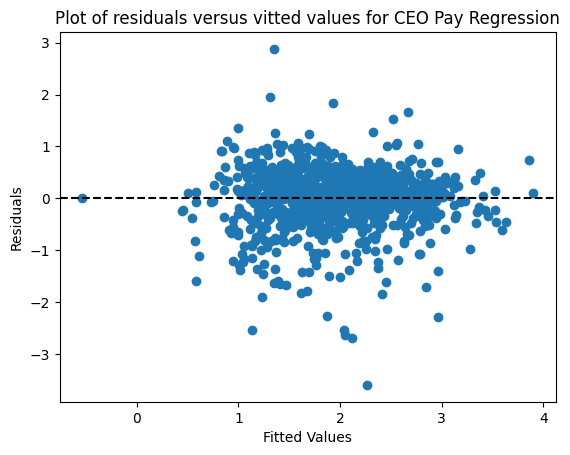

In [227]:
# Extract residuals and fitted values and do plot
resid=PayReg6.resid
yhat=PayReg6.fittedvalues
plt.scatter(yhat,resid)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Plot of residuals versus vitted values for CEO Pay Regression')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show

The smallest residual is for observation 235. Hence, pay is lowest among the 992 firms relative to the prediction of the model. This company is Copart. Copart operates an online auction platform where vehicles are bought and sold.  
The largest is for observation 725. Hence, pay is highest among the 992 firms relative to the prediction of the model.  This company is  Pinnacle Financial Partners, a financial services firm.

In [228]:
print(resid.idxmin(), resid.idxmax())

234 724


The Ramsey test yields high p-values, suggesting that this is a much improved functional form.

In [229]:
PayReg6.ramsey_test()

,power,pvalue
0,2,0.198944
1,3,0.406056


## Variation in Executive Compensation Across Industries

It is also of much interest to investigate the extent to which there is variation in pay across industries. Hence, I used the factor() command to include an indicator variable for each industry. As the reference category, I chose SIC code 36 (Electronic & Other Electric Equipment). There are 55 firms in our sample with this SIC code, including Apple. The output is lengthy, so I placed it in Appendix C. The coefficients of the market capitalization, employment, and gender variables for the model in Appendix C are very close in magnitude to the regression above.

Let's study the industry indicator variables. To facilitate interpretation, I selected the industries for which there are at least 10 firms in our sample and for which p-values of the coefficients are less than .051. I also calculated the percent pay difference (PctPayDiff) relative to the reference industry (SIC code 36). The results are in the table below. As you can see, there are large differences in CEO pay across industries holding constant market capitalization and number of employees.[^10_application_to_ceo_pay-11] In the highly paid group, the three most prominent are General Building Contractors, Communications, and Security & Commodity Brokers, with premia relative to the reference industry of 81%, 65%, and 58% respectively. On the opposite side, Electric & Gas & Sanitary Services, Depository Institutions, and Trucking & Warehousing pay are lower by 19%, 23%, and 38% respectively than the reference industry.

[^10_application_to_ceo_pay-11]: We have controlled for market capitalization and number of employees in the regression.

In [230]:
# TODO: Is this an indicator? Or are we just doing this to make SIC code 36 the reference category

# R
# SIC2 = ifelse(SIC2 == 36, 1, SIC2)

# Python
SIC2_reference_36 = numpy.where(SIC2 == 36, 1, SIC2)

In [231]:
FixEfDat = pandas.read_excel("data/SIC2_FE_and_Description.xlsx")

In [232]:
KeepFixe = FixEfDat[(FixEfDat['pval'] < 0.05) & (FixEfDat['Count'] > 9)]

In [233]:
KeepFixe

,SIC2,Coef,stderr,tstat,pval,Count,PctPayDiff,Activity
1,13,0.343261,0.100371,3.420,0.000654,26,40.953660,Oil & Gas Extraction
3,15,0.648454,0.134409,4.824,0.000002,15,91.258169,General Building Contractors
18,33,0.353585,0.122309,2.891,0.003931,14,42.416404,Primary Metal Industries
26,42,-0.417411,0.197390,-2.115,0.034726,10,-34.124988,Trucking & Warehousing
30,48,0.579477,0.148696,3.897,0.000104,18,78.510458,Communications
41,60,-0.199424,0.095397,-2.090,0.036848,65,-18.079752,Depository Institutions
42,61,0.458623,0.117587,3.900,0.000103,10,58.189422,Nondepository Institutions
43,62,0.537206,0.116812,4.599,0.000005,20,71.121903,Security & Commodity Brokers


## Summary

The above analysis provides you with an overview of firms in the US economy. The analysis also demonstrates the use of R software for summarizing data, fitting distributions to data, and conducting regression analysis. In addition, the analysis demonstrates the value of expressing variables in log form when the distributions of the variables are highly skewed. The regression in log form with industry indicator variables (Appendix C) has an adjusted $R^2$ value of .49. Thus, the logarithms of employment, market capitalization, and industry indicator variables predict roughly half of the variation in CEO compensation for the 992 firms in our data.

\newpage

## Appendix A: Table of SIC 2-digit Industries

In [234]:
SIC2_and_Descriptions_Numbers = pandas.read_excel("data/SIC2_and_Descriptions_Numbers.xlsx")
SIC2_and_Descriptions_Numbers

,SIC2,Activity
0,1,Agricultural Production & Crops
1,2,Agricultural Production & Livestock
2,7,Agricultural Services
3,8,Forestry
4,9,"Fishing, Hunting, & Trapping"
...,...,...
79,95,Environmental Quality & Housing
80,96,Administration of Economic Programs
81,97,National Security & International Affairs
82,98,Zoological Gardens


The following table lists the number of firms in each industry in our sample. Recall that our data set is made up of firms that have more than 99 employees and also have CEO compensation more than \$99,000. Some industries do not appear in our sample because they do not have any firms that meet these two criteria.

## Appendix B: Number of Firms By Industry in Our Sample

In [235]:
Count_SIC2_and_Activity = pandas.read_excel("data/Count_SIC2_and_Activity.xlsx")
Count_SIC2_and_Activity

,SIC2,Number,Activity
0,10,3,"Metal, Mining"
1,12,5,Coal Mining
2,13,26,Oil & Gas Extraction
3,14,6,"Nonmetallic Minerals, Except Fuels"
4,15,15,General Building Contractors
5,16,6,"Heavy Construction, Except Building"
6,17,5,Special Trade Contractors
7,20,29,Food & Kindred Products
8,22,4,Textile Mill Products
9,23,5,Apparel & Other Textile Products
